# Compare MZI, CNOT-chain, and Classical MLP

Notebook này đọc các history JSON đã sinh từ:

- `MZI-1layers-local-history.json` ... `MZI-5layers-local-history.json`
- `CNOT-chain-1layers-local-history.json` ... `CNOT-chain-5layers-local-history.json`
- `CLASSICAL-1layers-local-history.json` ... `CLASSICAL-5layers-local-history.json`

Nó so sánh loss, accuracy, training time, confusion matrix, recall/sensitivity,
precision, ROC-AUC, và bảng probabilities/predictions/labels.


Loaded histories: 9 / 9
Saved: C:\Quantum\ALLMODELS-final-metrics.csv
Saved: C:\Quantum\ALLMODELS-probabilities-predictions-labels.csv
Saved: C:\Quantum\ALLMODELS-epoch-history.csv


,model,model_key,layer,loss,accuracy,precision,recall_sensitivity,roc_auc,training_time_s,evaluation_time_s,total_wall_time_s,tn,fp,fn,tp,history_path
3,CNOT-chain,CNOT,1,1.122431e+00,0.866667,0.866667,0.866667,0.904444,14.934573,0.004098,14.938723,13,2,2,13,C:\Quantum\CNOT-chain-1layers-local-history.json
6,Classical MLP,CLASSICAL,1,6.295884e-06,1.000000,1.000000,1.000000,1.000000,1.475084,0.000216,1.475534,15,0,0,15,C:\Quantum\CLASSICAL-1layers-local-history.json
0,MZI,MZI,1,2.089506e-04,1.000000,1.000000,1.000000,1.000000,39.462527,0.010294,39.473040,15,0,0,15,C:\Quantum\MZI-1layers-local-history.json
4,CNOT-chain,CNOT,2,2.039813e-01,0.966667,1.000000,0.933333,1.000000,48.068743,0.011827,48.080639,15,0,1,14,C:\Quantum\CNOT-chain-2layers-local-history.json
7,Classical MLP,CLASSICAL,2,1.447809e-05,1.000000,1.000000,1.000000,1.000000,2.910213,0.000418,2.910911,15,0,0,15,C:\Quantum\CLASSICAL-2layers-local-history.json
1,MZI,MZI,2,2.825277e-04,1.000000,1.000000,1.000000,1.000000,61.483160,0.011626,61.494955,15,0,0,15,C:\Quantum\MZI-2layers-local-history.json
5,CNOT-chain,CNOT,3,1.577713e-02,1.000000,1.000000,1.000000,1.000000,72.740775,0.013797,72.754671,15,0,0,15,C:\Quantum\CNOT-chain-3layers-local-history.json
8,Classical MLP,CLASSICAL,3,4.682665e-08,1.000000,1.000000,1.000000,1.000000,3.779828,0.000723,3.780848,15,0,0,15,C:\Quantum\CLASSICAL-3layers-local-history.json
2,MZI,MZI,3,7.607069e-04,1.000000,1.000000,1.000000,1.000000,77.287128,0.012408,77.299773,15,0,0,15,C:\Quantum\MZI-3layers-local-history.json


Saved figure: C:\Quantum\ALLMODELS-final-metric-overview.png
Saved vector figure: C:\Quantum\ALLMODELS-final-metric-overview.pdf


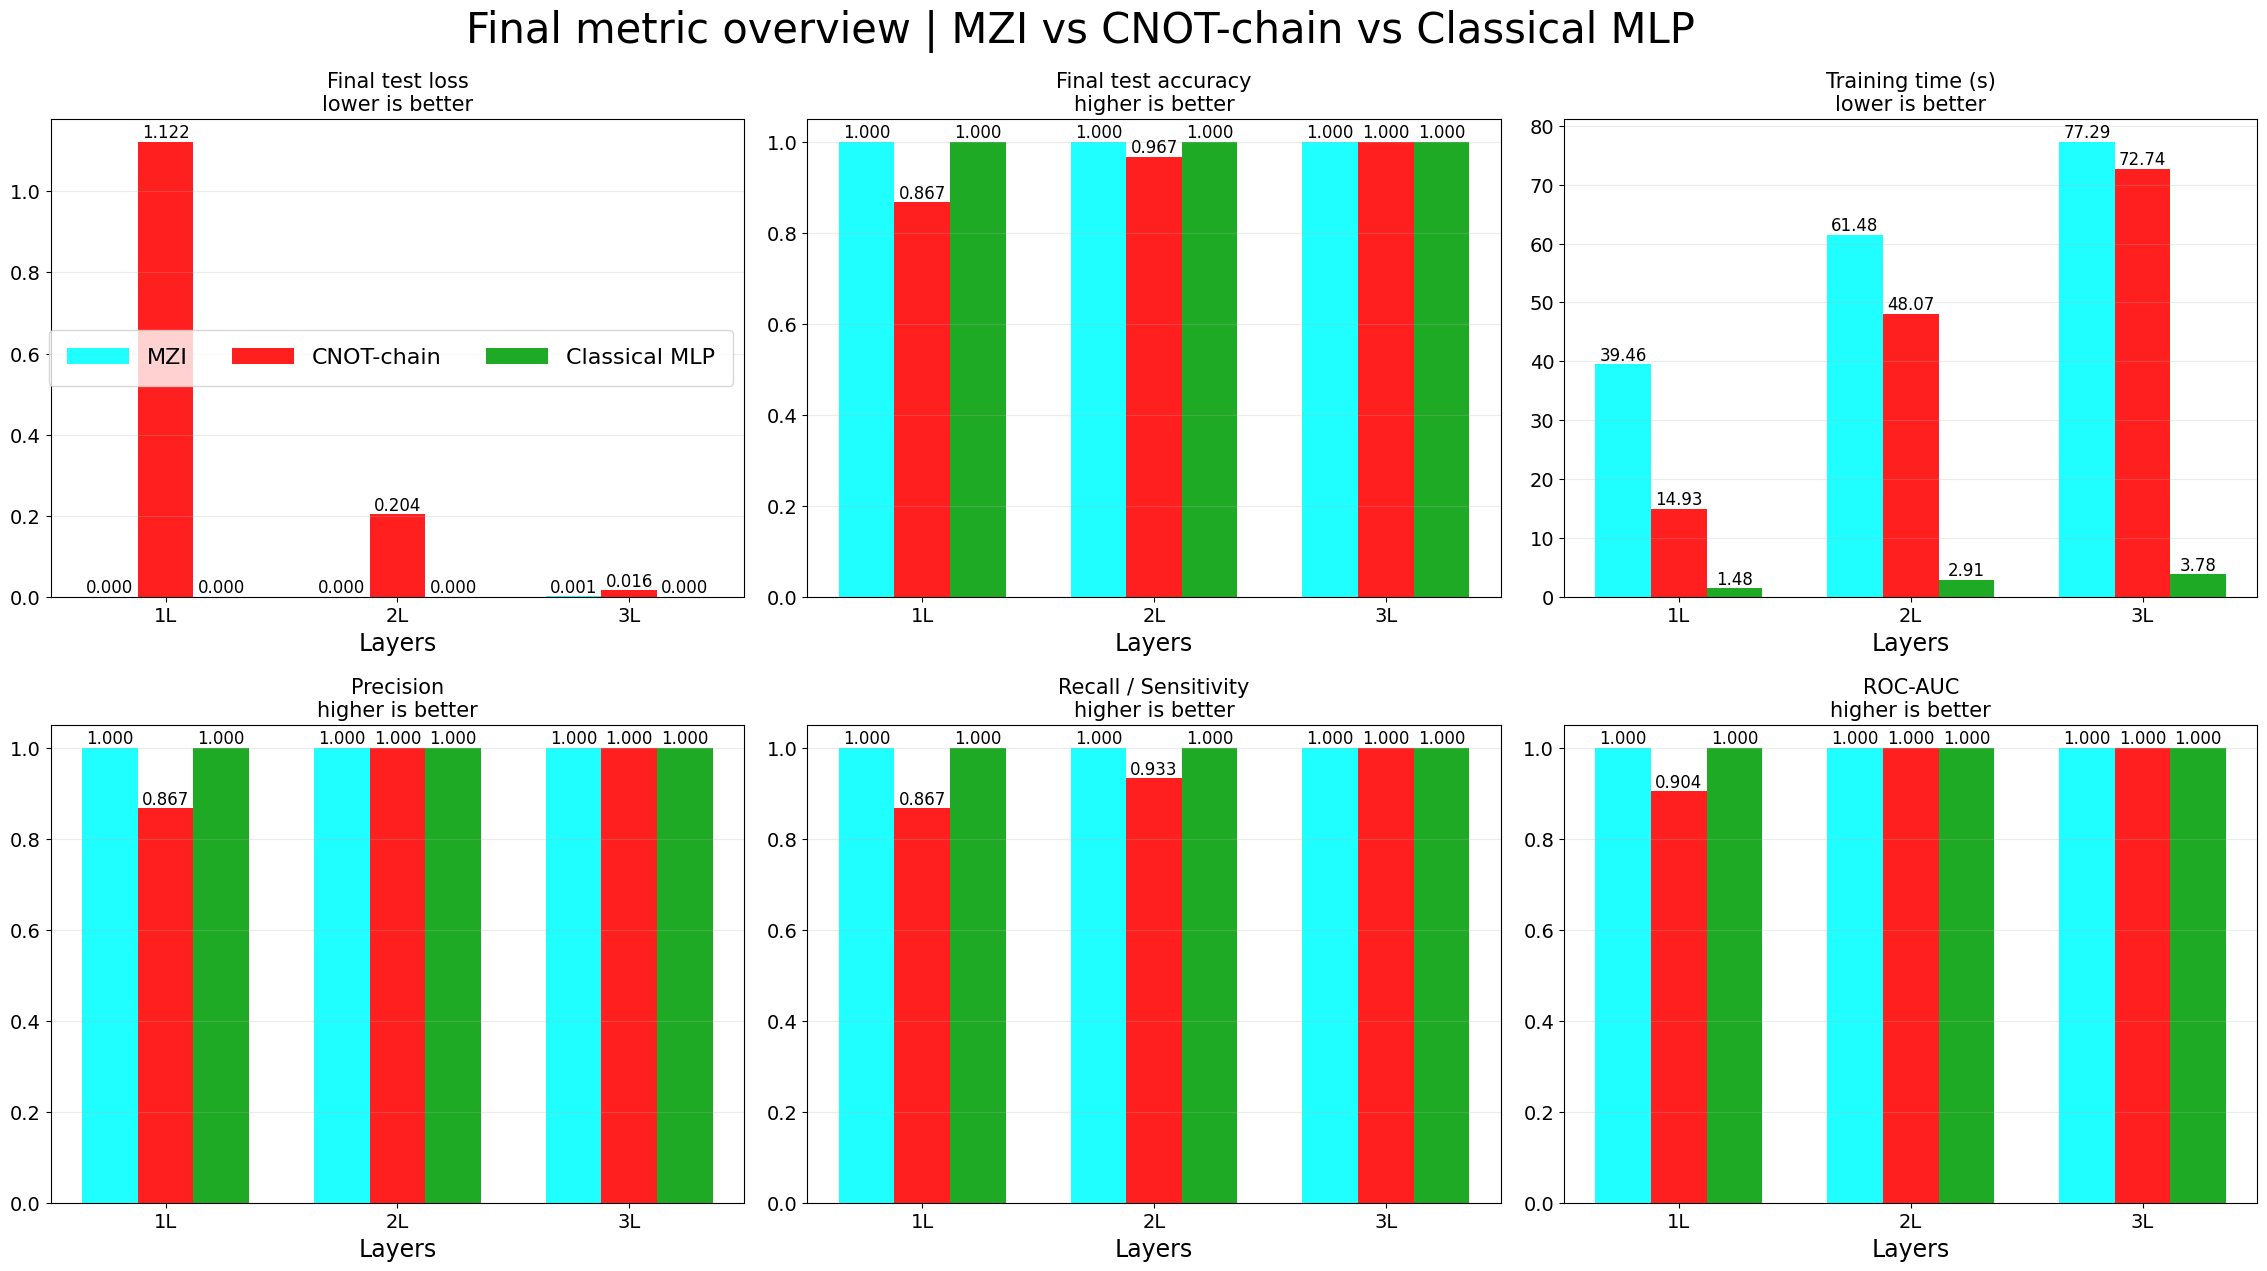

Saved figure: C:\Quantum\ALLMODELS-combined-test-loss-accuracy.png
Saved vector figure: C:\Quantum\ALLMODELS-combined-test-loss-accuracy.pdf


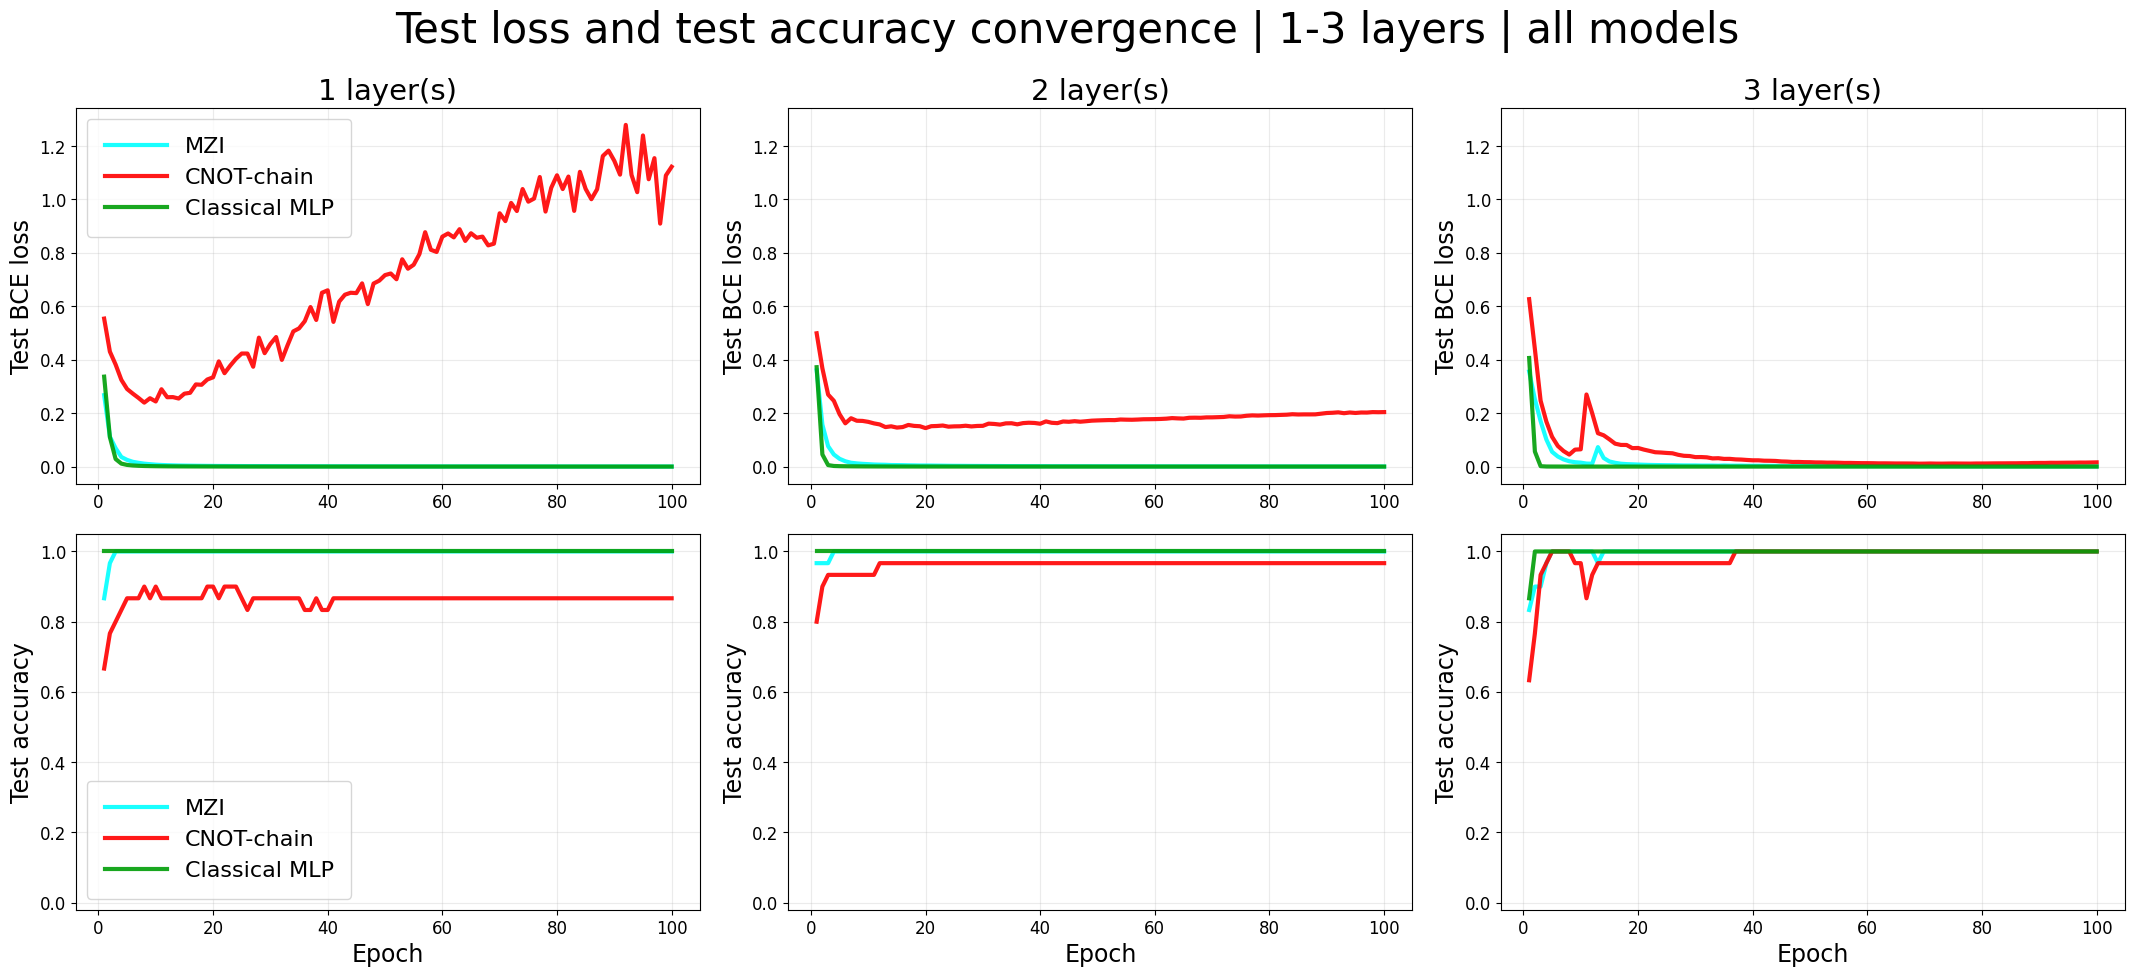

Saved figure: C:\Quantum\ALLMODELS-combined-confusion-matrices.png
Saved vector figure: C:\Quantum\ALLMODELS-combined-confusion-matrices.pdf


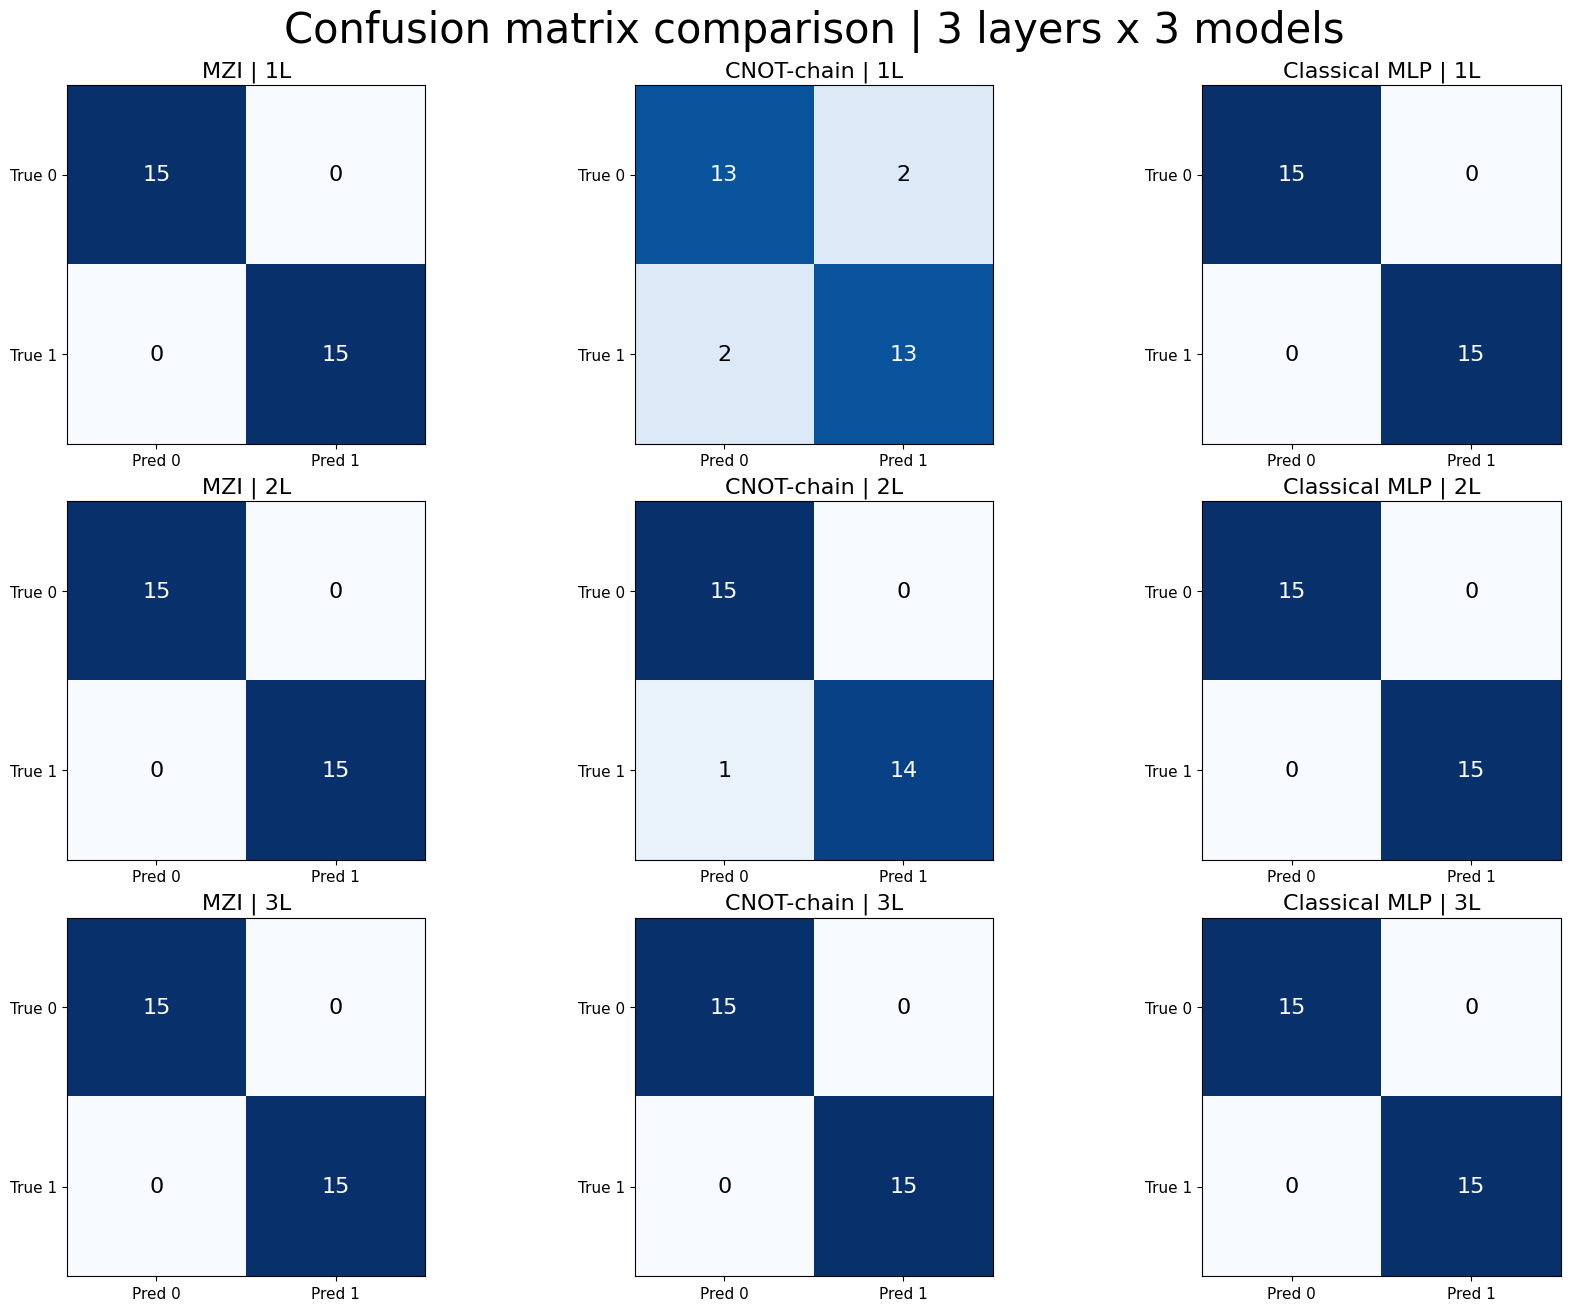

Saved figure: C:\Quantum\ALLMODELS-combined-probabilities-predictions-labels.png
Saved vector figure: C:\Quantum\ALLMODELS-combined-probabilities-predictions-labels.pdf


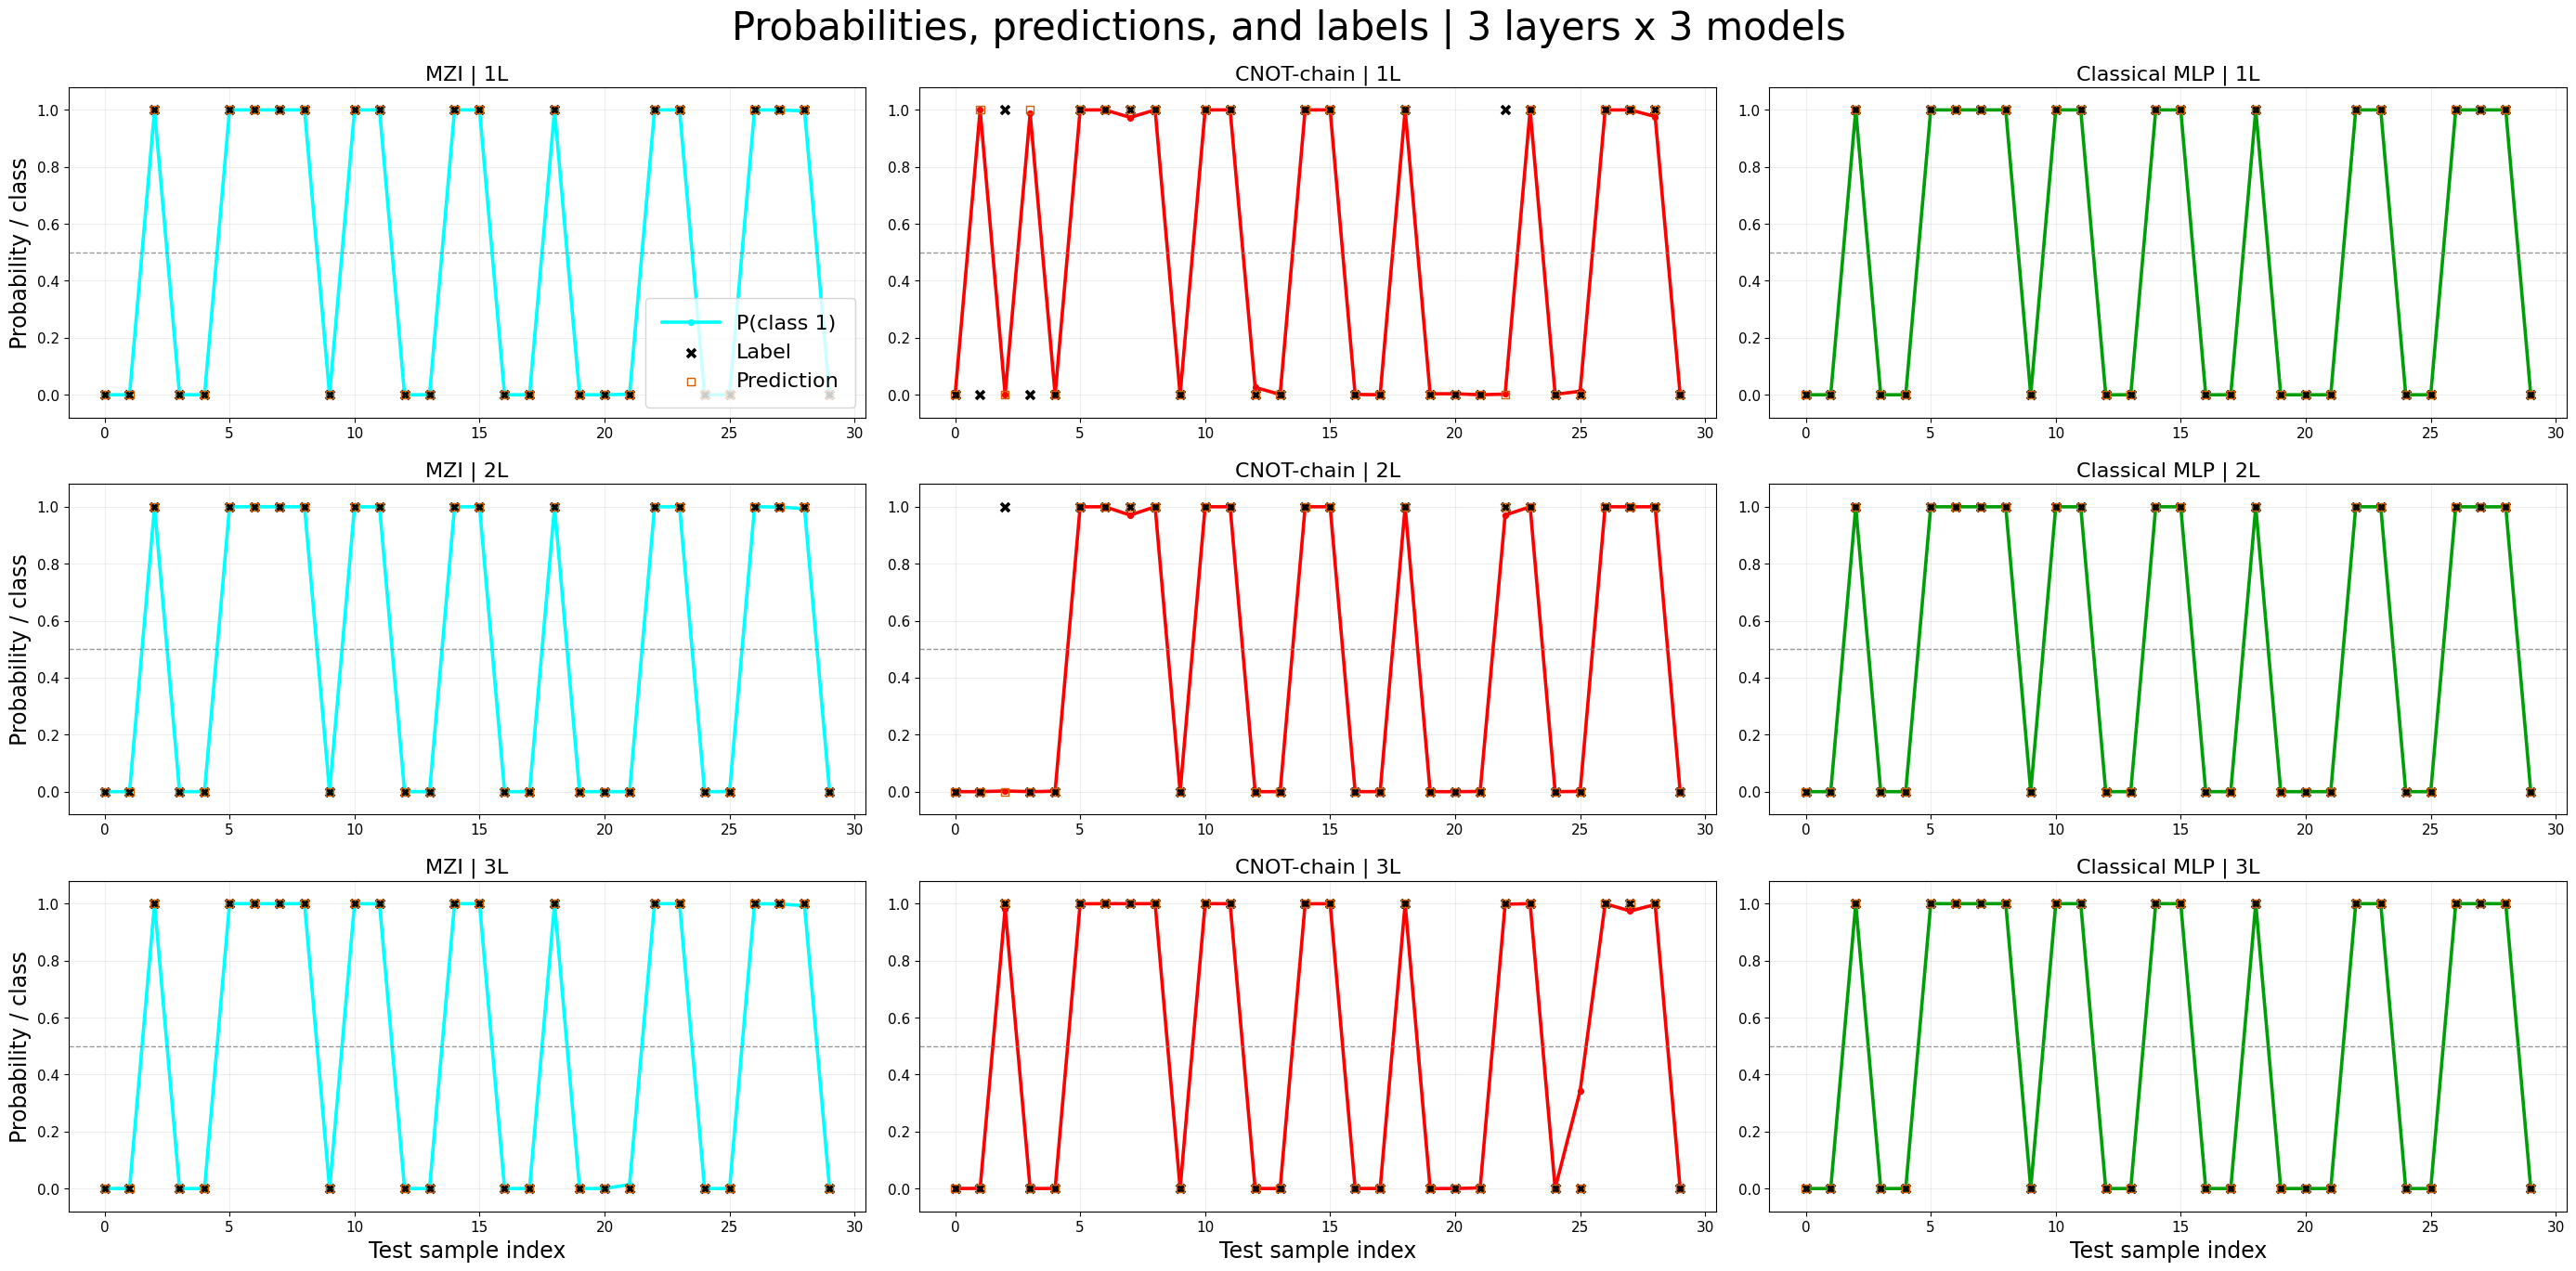

,model,model_key,layer,sample_id,label,prediction,probability_class_1,correct
90,CNOT-chain,CNOT,1,0,0,0,0.000041,1
180,Classical MLP,CLASSICAL,1,0,0,0,0.000046,1
0,MZI,MZI,1,0,0,0,0.000032,1
91,CNOT-chain,CNOT,1,1,0,1,1.000000,0
181,Classical MLP,CLASSICAL,1,1,0,0,0.000002,1
...,...,...,...,...,...,...,...,...
208,Classical MLP,CLASSICAL,1,28,1,1,1.000000,1
28,MZI,MZI,1,28,1,1,0.996744,1
119,CNOT-chain,CNOT,1,29,0,0,0.001038,1
209,Classical MLP,CLASSICAL,1,29,0,0,0.000002,1


In [13]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

try:
    import pandas as pd
except ImportError:
    pd = None


# ============================================================
# Configuration
# ============================================================

HISTORY_DIR = Path(r"C:\Quantum")
OUTPUT_DIR = HISTORY_DIR
LAYERS = [1, 2, 3]

MODEL_SPECS = [
    {
        "key": "MZI",
        "label": "MZI",
        "color": "#00FFFF",
        "filename": lambda layer: f"MZI-{layer}layers-local-history.json",
    },
    {
        "key": "CNOT",
        "label": "CNOT-chain",
        "color": "#FF0000",
        "filename": lambda layer: f"CNOT-chain-{layer}layers-local-history.json",
    },
    {
        "key": "CLASSICAL",
        "label": "Classical MLP",
        "color": "#009E08",
        "filename": lambda layer: f"CLASSICAL-{layer}layers-local-history.json",
    },
]


def safe_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def load_histories():
    histories = {}
    missing = []

    for spec in MODEL_SPECS:
        for layer in LAYERS:
            path = HISTORY_DIR / spec["filename"](layer)
            if not path.exists():
                missing.append(str(path))
                continue

            with open(path, "r", encoding="utf-8") as file:
                history = json.load(file)

            history["_model_key"] = spec["key"]
            history["_model_label"] = spec["label"]
            history["_color"] = spec["color"]
            history["_path"] = str(path)
            history["_layer"] = int(history.get("layers", layer))
            histories[(spec["key"], layer)] = history

    print(f"Loaded histories: {len(histories)} / {len(MODEL_SPECS) * len(LAYERS)}")
    if missing:
        print("Missing files:")
        for path in missing:
            print(" -", path)
    return histories


histories = load_histories()


# ============================================================
# Build summary/probability/epoch tables
# ============================================================

def build_summary_rows(histories):
    rows = []
    for spec in MODEL_SPECS:
        for layer in LAYERS:
            history = histories.get((spec["key"], layer))
            if history is None:
                continue

            final = history.get("final_test", {})
            timing = history.get("timing", {})
            matrix = final.get("confusion_matrix", [[np.nan, np.nan], [np.nan, np.nan]])
            matrix = np.array(matrix)
            tn, fp, fn, tp = (np.nan, np.nan, np.nan, np.nan)
            if matrix.shape == (2, 2):
                tn, fp, fn, tp = matrix.ravel()

            rows.append({
                "model": spec["label"],
                "model_key": spec["key"],
                "layer": layer,
                "loss": safe_float(final.get("loss")),
                "accuracy": safe_float(final.get("accuracy")),
                "precision": safe_float(final.get("precision")),
                "recall_sensitivity": safe_float(final.get("recall_sensitivity")),
                "roc_auc": safe_float(final.get("roc_auc")),
                "training_time_s": safe_float(timing.get("training_time_s")),
                "evaluation_time_s": safe_float(timing.get("evaluation_time_s")),
                "total_wall_time_s": safe_float(timing.get("total_wall_time_s")),
                "tn": int(tn) if not np.isnan(tn) else np.nan,
                "fp": int(fp) if not np.isnan(fp) else np.nan,
                "fn": int(fn) if not np.isnan(fn) else np.nan,
                "tp": int(tp) if not np.isnan(tp) else np.nan,
                "history_path": history.get("_path"),
            })
    return rows


def build_probability_rows(histories):
    rows = []
    for spec in MODEL_SPECS:
        for layer in LAYERS:
            history = histories.get((spec["key"], layer))
            if history is None:
                continue

            final = history.get("final_test", {})
            labels = final.get("labels", [])
            predictions = final.get("predictions", [])
            probabilities = final.get("probabilities", [])
            n_samples = min(len(labels), len(predictions), len(probabilities))

            for sample_id in range(n_samples):
                label = int(round(float(labels[sample_id])))
                prediction = int(round(float(predictions[sample_id])))
                probability = float(probabilities[sample_id])
                rows.append({
                    "model": spec["label"],
                    "model_key": spec["key"],
                    "layer": layer,
                    "sample_id": sample_id,
                    "label": label,
                    "prediction": prediction,
                    "probability_class_1": probability,
                    "correct": int(label == prediction),
                })
    return rows


def build_epoch_rows(histories):
    rows = []
    for spec in MODEL_SPECS:
        for layer in LAYERS:
            history = histories.get((spec["key"], layer))
            if history is None:
                continue

            epochs = history.get("epoch", [])
            for index, epoch in enumerate(epochs):
                rows.append({
                    "model": spec["label"],
                    "model_key": spec["key"],
                    "layer": layer,
                    "epoch": int(epoch),
                    "train_loss": safe_float(history.get("train_loss", [np.nan])[index]),
                    "test_loss": safe_float(history.get("test_loss", [np.nan])[index]),
                    "train_accuracy": safe_float(history.get("train_accuracy", [np.nan])[index]),
                    "test_accuracy": safe_float(history.get("test_accuracy", [np.nan])[index]),
                    "epoch_time_s": safe_float(history.get("epoch_time_s", [np.nan])[index]),
                })
    return rows


summary_rows = build_summary_rows(histories)
probability_rows = build_probability_rows(histories)
epoch_rows = build_epoch_rows(histories)

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    probability_df = pd.DataFrame(probability_rows)
    epoch_df = pd.DataFrame(epoch_rows)

    summary_path = OUTPUT_DIR / "ALLMODELS-final-metrics.csv"
    probability_path = OUTPUT_DIR / "ALLMODELS-probabilities-predictions-labels.csv"
    epoch_path = OUTPUT_DIR / "ALLMODELS-epoch-history.csv"

    summary_df.to_csv(summary_path, index=False)
    probability_df.to_csv(probability_path, index=False)
    epoch_df.to_csv(epoch_path, index=False)

    print("Saved:", summary_path)
    print("Saved:", probability_path)
    print("Saved:", epoch_path)
    display(summary_df.sort_values(["layer", "model"]))
else:
    print("pandas is not installed. Tables are available as Python lists:")
    print("summary_rows, probability_rows, epoch_rows")
    print("First summary row:", summary_rows[0] if summary_rows else None)

# ============================================================
# Combined dashboard plots
# ============================================================

def history_for(model_key, layer):
    return histories.get((model_key, layer))


def model_color(model_key):
    for spec in MODEL_SPECS:
        if spec["key"] == model_key:
            return spec["color"]
    return "gray"


def model_label(model_key):
    for spec in MODEL_SPECS:
        if spec["key"] == model_key:
            return spec["label"]
    return model_key


EXPORT_DPI = 600
LEGEND_FONTSIZE = 16
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": LEGEND_FONTSIZE,
    "legend.title_fontsize": LEGEND_FONTSIZE,
    "figure.titlesize": 30,
    "lines.linewidth": 2.6,
})


def available_models_for_layer(layer):
    return [spec for spec in MODEL_SPECS if (spec["key"], layer) in histories]


def final_metric(history, metric):
    if history is None:
        return np.nan
    if metric == "training_time_s":
        return safe_float(history.get("timing", {}).get("training_time_s"))
    return safe_float(history.get("final_test", {}).get(metric))


def maybe_savefig(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=EXPORT_DPI, bbox_inches="tight")
    pdf_path = path.with_suffix(".pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved figure:", path)
    print("Saved vector figure:", pdf_path)


def plot_final_metric_overview():
    metric_specs = [
        ("loss", "Final test loss", "lower is better"),
        ("accuracy", "Final test accuracy", "higher is better"),
        ("training_time_s", "Training time (s)", "lower is better"),
        ("precision", "Precision", "higher is better"),
        ("recall_sensitivity", "Recall / Sensitivity", "higher is better"),
        ("roc_auc", "ROC-AUC", "higher is better"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(24, 13))
    axes = axes.ravel()
    x = np.arange(len(LAYERS))
    bar_width = 0.24

    for ax, (metric, title, subtitle) in zip(axes, metric_specs):
        for model_index, spec in enumerate(MODEL_SPECS):
            values = [final_metric(history_for(spec["key"], layer), metric) for layer in LAYERS]
            offsets = x + (model_index - 1) * bar_width
            bars = ax.bar(
                offsets,
                values,
                width=bar_width,
                label=spec["label"],
                color=spec["color"],
                alpha=0.88,
            )
            for bar, value in zip(bars, values):
                if np.isnan(value):
                    continue
                text = f"{value:.2f}" if metric == "training_time_s" else f"{value:.3f}"
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    text,
                    ha="center",
                    va="bottom",
                    fontsize=12,
                    rotation=0,
                )

        ax.set_title(f"{title}\n{subtitle}", fontsize=15)
        ax.set_xticks(x, labels=[f"{layer}L" for layer in LAYERS])
        ax.set_xlabel("Layers")
        ax.grid(axis="y", alpha=0.25)

    axes[0].legend(ncol=3, fontsize=LEGEND_FONTSIZE, frameon=True, borderpad=0.8, handlelength=2.8)
    fig.suptitle("Final metric overview | MZI vs CNOT-chain vs Classical MLP", fontsize=30)
    fig.tight_layout()
    maybe_savefig(fig, "ALLMODELS-final-metric-overview.png")
    plt.show()


def plot_combined_test_loss_accuracy():
    """One figure for selected layers. Train curves are intentionally omitted."""
    fig, axes = plt.subplots(
        2,
        len(LAYERS),
        figsize=(7.2 * len(LAYERS), 10),
        sharex=False,
        sharey="row",
    )

    for col, layer in enumerate(LAYERS):
        loss_ax = axes[0, col]
        acc_ax = axes[1, col]

        for spec in available_models_for_layer(layer):
            history = history_for(spec["key"], layer)
            epochs = np.array(history.get("epoch", []), dtype=float)
            test_loss = np.array(history.get("test_loss", []), dtype=float)
            test_accuracy = np.array(history.get("test_accuracy", []), dtype=float)

            if len(epochs) == 0:
                continue

            loss_ax.plot(
                epochs,
                test_loss,
                color=spec["color"],
                linewidth=3.0,
                alpha=0.9,
                label=spec["label"],
            )
            acc_ax.plot(
                epochs,
                test_accuracy,
                color=spec["color"],
                linewidth=3.0,
                alpha=0.9,
                label=spec["label"],
            )

        loss_ax.set_title(f"{layer} layer(s)", fontsize=21)
        loss_ax.set_ylabel("Test BCE loss")
        loss_ax.tick_params(axis="y", labelleft=True)
        loss_ax.tick_params(axis="both", labelsize=12)
        loss_ax.grid(alpha=0.25)

        acc_ax.set_xlabel("Epoch")
        acc_ax.set_ylabel("Test accuracy")
        acc_ax.tick_params(axis="y", labelleft=True)
        acc_ax.tick_params(axis="both", labelsize=12)
        acc_ax.set_ylim(-0.02, 1.05)
        acc_ax.grid(alpha=0.25)

        if col == 0:
            loss_ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True, borderpad=0.8, handlelength=2.8)
            acc_ax.legend(fontsize=LEGEND_FONTSIZE, frameon=True, borderpad=0.8, handlelength=2.8)

    fig.suptitle(
        "Test loss and test accuracy convergence | 1-3 layers | all models",
        fontsize=30,
    )
    fig.tight_layout()
    maybe_savefig(fig, "ALLMODELS-combined-test-loss-accuracy.png")
    plt.show()


def collect_confusion_max():
    max_value = 1
    for spec in MODEL_SPECS:
        for layer in LAYERS:
            history = history_for(spec["key"], layer)
            if history is None:
                continue
            matrix = np.array(history.get("final_test", {}).get("confusion_matrix", [[0, 0], [0, 0]]))
            if matrix.size:
                max_value = max(max_value, int(np.nanmax(matrix)))
    return max_value


def plot_combined_confusion_matrices():
    vmax = collect_confusion_max()
    fig, axes = plt.subplots(
        len(LAYERS),
        len(MODEL_SPECS),
        figsize=(17, 13),
        squeeze=False,
        constrained_layout=True,
    )

    for row, layer in enumerate(LAYERS):
        for col, spec in enumerate(MODEL_SPECS):
            ax = axes[row, col]
            history = history_for(spec["key"], layer)
            if history is None:
                ax.axis("off")
                ax.set_title(f"{spec['label']} {layer}L missing")
                continue

            matrix = np.array(
                history.get("final_test", {}).get("confusion_matrix", [[0, 0], [0, 0]]),
                dtype=float,
            )
            ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
            ax.set_title(f"{spec['label']} | {layer}L", fontsize=16)
            ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"], fontsize=11)
            ax.set_yticks([0, 1], labels=["True 0", "True 1"], fontsize=11)

            for i in range(2):
                for j in range(2):
                    value = int(matrix[i, j])
                    color = "white" if value > 0.55 * vmax else "black"
                    ax.text(j, i, value, ha="center", va="center", fontsize=16, color=color)

    fig.suptitle("Confusion matrix comparison | 3 layers x 3 models", fontsize=30)
    maybe_savefig(fig, "ALLMODELS-combined-confusion-matrices.png")
    plt.show()


def plot_combined_probabilities_predictions_labels():
    fig, axes = plt.subplots(len(LAYERS), len(MODEL_SPECS), figsize=(28, 14), squeeze=False, sharey=True)

    for row, layer in enumerate(LAYERS):
        for col, spec in enumerate(MODEL_SPECS):
            ax = axes[row, col]
            history = history_for(spec["key"], layer)
            if history is None:
                ax.axis("off")
                ax.set_title(f"{spec['label']} {layer}L missing")
                continue

            final = history.get("final_test", {})
            labels = np.array(final.get("labels", []), dtype=float).reshape(-1)
            predictions = np.array(final.get("predictions", []), dtype=float).reshape(-1)
            probabilities = np.array(final.get("probabilities", []), dtype=float).reshape(-1)
            n_samples = min(len(labels), len(predictions), len(probabilities))
            sample_ids = np.arange(n_samples)

            labels = labels[:n_samples]
            predictions = predictions[:n_samples]
            probabilities = probabilities[:n_samples]

            ax.plot(sample_ids, probabilities, marker="o", markersize=4.2, linewidth=2.6,
                    color=spec["color"], label="P(class 1)")
            ax.scatter(sample_ids, labels, marker="x", s=42, color="black", label="Label", zorder=3)
            ax.scatter(sample_ids, predictions, marker="s", s=34, facecolors="none",
                       edgecolors="#D55E00", label="Prediction", zorder=3)
            ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.8)

            ax.set_ylim(-0.08, 1.08)
            ax.tick_params(axis="y", labelleft=True)
            ax.tick_params(axis="both", labelsize=11)
            ax.grid(alpha=0.22)
            ax.set_title(f"{spec['label']} | {layer}L", fontsize=16)
            if col == 0:
                ax.set_ylabel("Probability / class")
            if row == len(LAYERS) - 1:
                ax.set_xlabel("Test sample index")
            if row == 0 and col == 0:
                ax.legend(loc="lower right", fontsize=LEGEND_FONTSIZE, frameon=True, borderpad=0.8, handlelength=2.8)

    fig.suptitle(
        "Probabilities, predictions, and labels | 3 layers x 3 models",
        fontsize=30,
    )
    fig.tight_layout()
    maybe_savefig(fig, "ALLMODELS-combined-probabilities-predictions-labels.png")
    plt.show()


plot_final_metric_overview()
plot_combined_test_loss_accuracy()
plot_combined_confusion_matrices()
plot_combined_probabilities_predictions_labels()


# ============================================================
# Probability table preview
# ============================================================

if pd is not None:
    display(probability_df.sort_values(["layer", "sample_id", "model"]).head(90))
else:
    probability_rows[:10]


In [3]:
plt.savefig("ALLMODELS-combined-probabilities-predictions-labels.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [4]:
import os

print("Current folder:", os.getcwd())
print("Files in this folder:")
print(os.listdir())

Current folder: c:\Quantum
Files in this folder:
['3 layers.backup-before-belenos.ipynb', '3 layers.backup-before-slos-merlin.ipynb', 'A1.ipynb', 'Air time quality.ipynb', 'ALLMODELS-combined-confusion-matrices.png', 'ALLMODELS-combined-probabilities-predictions-labels.pdf', 'ALLMODELS-combined-probabilities-predictions-labels.png', 'ALLMODELS-combined-test-loss-accuracy.png', 'ALLMODELS-epoch-history.csv', 'ALLMODELS-final-metric-overview.png', 'ALLMODELS-final-metrics.csv', 'ALLMODELS-probabilities-predictions-labels.csv', 'assignment1_kronig_penney.py', 'assignment2_density_of_states.py', 'benchmark_3way.png', 'check_fid.py', 'CLASSICAL-1layer.ipynb', 'CLASSICAL-1layers-local-history.json', 'CLASSICAL-2layers-local-history.json', 'CLASSICAL-2layers.ipynb', 'CLASSICAL-3layers-local-history.json', 'CLASSICAL-3layers.ipynb', 'CLASSICAL-4layers-local-history.json', 'CLASSICAL-4layers.ipynb', 'CLASSICAL-5layers-local-history.json', 'CLASSICAL-5layers.ipynb', 'CNOT-1layer.ipynb', 'CNOT-2l

In [5]:
import os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

plt.savefig("figures/qnn_probability_prediction_label.pdf", bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [6]:
os.getcwd()

'c:\\Quantum'